#AI and GenAI Assignment

####1. Data Loading and Preprocessing

load the MNIST dataset and scale it to the $[-1, 1]$ range as specified.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def prepare_data():
    #Load the MNIST dataset
    (x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

    #Normalize the data to the range [-1, 1] and reshape to (28, 28, 1)
    x_train = (x_train.astype('float32') - 127.5) / 127.5
    x_train = np.expand_dims(x_train, axis=-1)

    #Shuffle and batch
    train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(256)
    return train_dataset

train_dataset = prepare_data()

####2. Generator Network Design

In [ ]:
def build_generator():
    model = tf.keras.Sequential([
        #Input: 100-dimensional noise vector
        layers.Input(shape=(100,)),

        #Layers: Dense -> BatchNormalization -> LeakyReLU
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        #Conv2DTranspose layers to upscale to 28x28
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        #Output (Tanh)
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

####3. Discriminator Network Design

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        #Layers: Conv2D -> LeakyReLU -> Dropout
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        #Flatten -> Dense (Sigmoid)
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

####4. Loss and Optimizer Configuration

In [ ]:
generator = build_generator()
discriminator = build_discriminator()
cross_entropy = tf.keras.losses.BinaryCrossentropy() # Binary Cross-Entropy (BCE)

#Optimizer: Adam (learning rate = 0.0002, beta1 = 0.5)
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

#### 5. Training Loop Definitio

In [ ]:
noise_dim = 100
gen_loss_history = []
disc_loss_history = []

@tf.function
def train_step(images):
    noise = tf.random.normal([256, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        #Calculate losses
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    #Apply Gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

####6. Execution and Visualization

Epoch 1 / 20


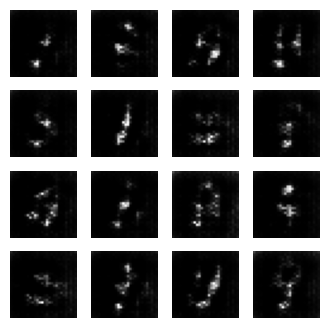

Epoch 5 / 20


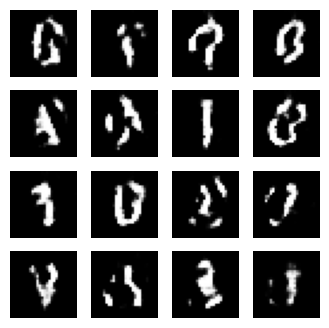

Epoch 10 / 20


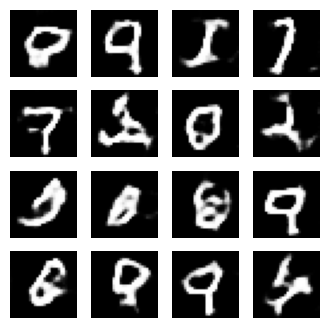

Epoch 15 / 20


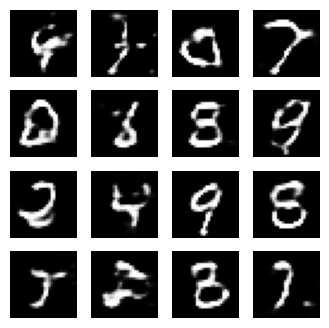

Epoch 20 / 20


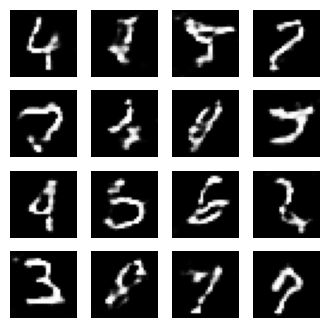

In [7]:
def train_gan(dataset, epochs):
    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss.append(g_loss)
            epoch_disc_loss.append(d_loss)

        gen_loss_history.append(np.mean(epoch_gen_loss))
        disc_loss_history.append(np.mean(epoch_disc_loss))

        # Visualize progress every few epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1} / {epochs}')
            display_images(generator)

def display_images(model):
    test_input = tf.random.normal([16, 100])
    predictions = model(test_input, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        # Rescale back to [0, 255] for plotting
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.show()

#Run training for at least 20 epochs
train_gan(train_dataset, 20)

####7. Final Output: Plot loss curves

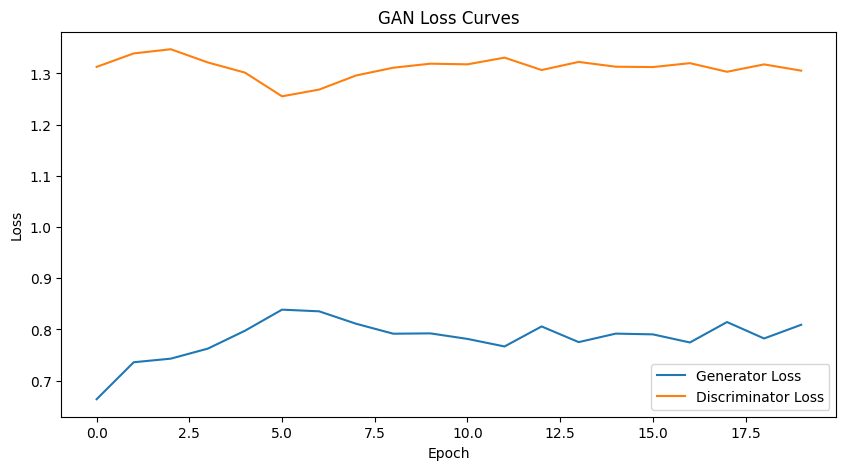

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(gen_loss_history, label='Generator Loss')
plt.plot(disc_loss_history, label='Discriminator Loss')
plt.title("GAN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



###Objective & GAN Explanation Objective:
 To implement and train a GAN using TensorFlow to generate handwritten digits resembling the MNIST dataset.GAN Basics: Explain the adversarial relationship between the Generator (creating fakes) and the Discriminator (detecting fakes).
###Architecture Summary Use a table to summarize the layers you implemented:
 Generator: Input (100) → Dense → BatchNormalization → LeakyReLU → Reshape → Conv2DTranspose → Tanh.Discriminator: Input (28x28x1) → Conv2D → LeakyReLU → Dropout → Flatten → Dense (Sigmoid).
###Results & Visualization Loss Curves:
 Use plt.plot(gen_losses) and plt.plot(disc_losses) to show the competition between models.Sample Outputs: Include
###Observations & Challenges Observations:
 Note how the images transitioned from random noise to recognizable digits over 20 epochs.Challenges: Mention handling the Keras UserWarning by switching to explicit Input() layers to ensure API compatibility.